In [138]:
import numpy as np
import xarray as xr
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [139]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean.nc")
df = era5.to_dataframe()
df = df.drop(columns=['number', 'spatial_ref'])
df

,tp,pev,e,evabs,evavt,ro,sro,ssro,smlt,slhf,...,t2m,d2m,skt,stl1,stl2,sd,swvl1,swvl2,swvl3,swvl4
time,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.101248,8.489518,2.051641,0.769473,0.151967,0.012130,0.009983,0.002145,0.050728,-1425.284546,...,6.852386,0.166043,5.791415,6.971447,7.973609,0.000095,0.354128,0.342383,0.206956,0.185093
2010-01-02,0.079038,3.869052,1.241719,0.667134,0.067932,0.003548,0.001396,0.002150,0.037054,-862.550049,...,5.628596,1.466584,4.313365,5.700845,6.929776,0.000077,0.344654,0.337573,0.208640,0.185096
2010-01-03,3.059302,1.379530,0.588521,0.313155,0.008895,0.028894,0.026737,0.002156,0.022783,-408.796539,...,5.449756,3.317313,4.290583,5.208694,6.142272,0.000063,0.346503,0.333589,0.210016,0.185100
2010-01-04,3.088892,1.446424,0.838293,0.205552,0.001132,0.030507,0.028344,0.002163,0.027599,-582.296021,...,6.981274,5.100214,6.473329,6.689444,6.798848,0.000054,0.361120,0.333588,0.211288,0.185106
2010-01-05,7.824946,1.715469,1.041873,0.109919,0.010273,0.086526,0.084356,0.002171,0.032366,-723.722412,...,6.825509,4.307442,6.497341,7.130359,7.634218,0.000062,0.395462,0.348562,0.212810,0.185112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-26,0.229120,8.578738,1.786239,0.761648,0.170509,0.015341,0.001438,0.013902,0.001159,-1240.849365,...,6.609004,-1.086839,5.947797,7.710899,9.505402,0.000004,0.273151,0.265320,0.202990,0.216090
2025-11-27,0.012070,5.709298,1.485819,0.719173,0.112032,0.013972,0.000084,0.013882,0.000857,-1032.150879,...,5.946863,-1.581570,4.714694,6.512339,8.412835,0.000003,0.264714,0.263807,0.203156,0.216078
2025-11-28,0.001319,3.045781,1.062401,0.612364,0.024981,0.013894,0.000027,0.013862,0.001447,-738.014587,...,6.621206,0.645134,5.179995,6.448483,7.863107,0.000003,0.258665,0.262235,0.203307,0.216065


In [140]:
nan_rows = df[df.isna().any(axis=1)]
print("Days with missing values:")
print(nan_rows)

Days with missing values:
Empty DataFrame
Columns: [tp, pev, e, evabs, evavt, ro, sro, ssro, smlt, slhf, ssr, ssrd, str, strd, t2m, d2m, skt, stl1, stl2, sd, swvl1, swvl2, swvl3, swvl4]
Index: []

[0 rows x 24 columns]


ERA5-Land Variables Description - 24 features

🌧️ Atmospheric Forcing (Water & Energy Inputs)

- tp – Total precipitation (m). Total rainfall and snowfall.

- ssrd – Surface solar radiation downward (J/m²). Incoming shortwave radiation at the surface.

- strd – Surface thermal radiation downward (J/m²). Incoming longwave radiation at the surface.

- d2m – 2-meter dewpoint temperature (K). Represents near-surface atmospheric moisture; useful for humidity and vapor pressure deficit calculations.

- t2m – 2-meter air temperature (K). Standard near-surface air temperature; key driver of evapotranspiration and drought development.

☀️ Surface Energy Balance

- ssr – Surface net solar (shortwave) radiation (J/m²). Net shortwave energy at the surface.

- str – Surface net thermal (longwave) radiation (J/m²). Net longwave radiation at the surface.

- skt – Skin temperature (K). Temperature of the land surface “skin”; responds quickly to radiation and soil moisture changes.

- slhf – Surface latent heat flux (J/m²). Energy used for evaporation and transpiration.

💧 Evaporation & Evaporative Demand

- e – Total evaporation (m). Sum of evaporation components (soil + vegetation + interception).

- evabs – Evaporation from bare soil (m). Water evaporated directly from soil surface.

- evavt – Evaporation from vegetation transpiration (m). Plant transpiration component of evapotranspiration.

- pev – Potential evaporation (m). Maximum possible evaporation under unlimited water supply.

🌱 Soil Moisture State (Water Storage)

- swvl1 – Volumetric soil water content layer 1 (0–7 cm, m³/m³). Surface soil moisture.

- swvl2 – Volumetric soil water content layer 2 (7–28 cm, m³/m³). Shallow root-zone soil moisture.

- swvl3 – Volumetric soil water content layer 3 (28–100 cm, m³/m³). Deeper root-zone soil moisture.

- swvl4 – Volumetric soil water content layer 4 (100–289 cm, m³/m³). Deep soil moisture storage.

🌡️ Soil Thermal State

- stl1 – Soil temperature layer 1 (0–7 cm, K). Temperature of the top soil layer.

- stl2 – Soil temperature layer 2 (7–28 cm, K). Temperature of the shallow subsurface layer.

❄️ Snow Processes

- sd – Snow depth (m of water equivalent). Total depth of snowpack.

- smlt – Snowmelt (m water equivalent). Amount of melted snow contributing to surface water.

🌊 Runoff & Drainage (Water Outputs)

- ro – Total runoff (m). Combined surface and subsurface runoff.

- ssro – Surface runoff (m). Direct runoff from precipitation/snowmelt at surface.

- sro – Subsurface runoff (m). Drainage and lateral flow below the surface.

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seeds(seed=2):
    # Set basic Python/Numpy seeds
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    
    # Set TF seed
    tf.random.set_seed(seed)
    
    # Force determinism (The "Big Hammer")
    # This replaces the need for the environment variable in newer TF versions
    tf.config.experimental.enable_op_determinism() 
    
    # If using GPU, some ops still might be non-deterministic
    # This environment variable is a good backup
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_seeds(2)

Feature importances with random forest

In [142]:
df["target"] = df["swvl1"].shift(-1)
df_model = df.dropna()
drop_cols = ["target"]#, "swvl1"]

df_model['month'] = df_model.index.month
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['day_of_year'] = df_model.index.dayofyear
df_model['tp_30d_sum'] = df_model['tp'].rolling(window=30, center=False).sum()
df_model['tp_90d_sum'] = df_model['tp'].rolling(window=90, center=False).sum()
df_model['t2m_30d_mean'] = df_model['t2m'].rolling(window=30, center=False).mean()
df_model['skt_30d_mean'] = df_model['skt'].rolling(window=30, center=False).mean()
df_model['tp_30d_mean'] = df_model['tp'].rolling(window=30, center=False).mean()

X = df_model.drop(columns=drop_cols)
y = df_model["target"]

split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,            # Cap the depth to prevent "memorization"
    min_samples_leaf=50,      # Each leaf must have at least 5 samples
    max_features=0.5,        # Look at only 50% of features per split
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# print("R²:", r2)
# print("RMSE:", rmse)
# print("MAE:", mae)

# Predict on both sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Compare R²
# print(f"Train R²: {r2_score(y_train, y_train_pred)}")
# print(f"Test R²: {r2_score(y_test, y_test_pred)}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3274291544.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month'] = df_model.index.month
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3274291544.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3274291544.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

swvl1           0.577268
swvl2           0.221548
skt             0.068204
stl1            0.038051
sro             0.023231
str             0.016989
t2m             0.013911
pev             0.009123
tp              0.009039
ro              0.004611
ssr             0.003576
stl2            0.002585
tp_30d_sum      0.002084
t2m_30d_mean    0.001690
tp_30d_mean     0.001581
tp_90d_sum      0.001466
e               0.001351
ssrd            0.001218
slhf            0.001050
evabs           0.000915
month_cos       0.000138
skt_30d_mean    0.000076
swvl3           0.000059
day_of_year     0.000058
d2m             0.000046
evavt           0.000037
swvl4           0.000026
strd            0.000020
smlt            0.000020
ssro            0.000017
sd              0.000011
month           0.000001
dtype: float64


In [143]:
df["target"] = df["swvl1"].shift(-7)
df_model = df.dropna()
drop_cols = ["target"]#, "swvl1"]

df_model['month'] = df_model.index.month
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['day_of_year'] = df_model.index.dayofyear
df_model['tp_30d_sum'] = df_model['tp'].rolling(window=30, center=False).sum()
df_model['tp_90d_sum'] = df_model['tp'].rolling(window=90, center=False).sum()
df_model['t2m_30d_mean'] = df_model['t2m'].rolling(window=30, center=False).mean()
df_model['skt_30d_mean'] = df_model['skt'].rolling(window=30, center=False).mean()
df_model['tp_30d_mean'] = df_model['tp'].rolling(window=30, center=False).mean()

X = df_model.drop(columns=drop_cols)
y = df_model["target"]

split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,            # Cap the depth to prevent "memorization"
    min_samples_leaf=50,      # Each leaf must have at least 5 samples
    max_features=0.5,        # Look at only 50% of features per split
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# print("R²:", r2)
# print("RMSE:", rmse)
# print("MAE:", mae)

# Predict on both sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Compare R²
# print(f"Train R²: {r2_score(y_train, y_train_pred)}")
# print(f"Test R²: {r2_score(y_test, y_test_pred)}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

C:\Users\albat\AppData\Local\Temp\ipykernel_10228\2366128208.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month'] = df_model.index.month
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\2366128208.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\2366128208.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

swvl2           0.253150
swvl1           0.250322
stl1            0.141624
skt             0.138820
ssr             0.031634
ssrd            0.029281
stl2            0.022126
t2m             0.019209
pev             0.017421
tp_30d_sum      0.010693
tp_30d_mean     0.010685
month_cos       0.009630
day_of_year     0.008342
skt_30d_mean    0.007663
swvl3           0.006800
e               0.005279
slhf            0.005138
t2m_30d_mean    0.004532
tp_90d_sum      0.004468
ssro            0.004288
str             0.004128
swvl4           0.003059
evabs           0.002713
d2m             0.002104
ro              0.001161
sro             0.001143
tp              0.001140
sd              0.000893
smlt            0.000872
strd            0.000677
evavt           0.000557
month           0.000447
dtype: float64


In [144]:
df["target"] = df["swvl1"].shift(-14)
df_model = df.dropna()
drop_cols = ["target"]#, "swvl1"]

df_model['month'] = df_model.index.month
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['day_of_year'] = df_model.index.dayofyear
df_model['tp_30d_sum'] = df_model['tp'].rolling(window=30, center=False).sum()
df_model['tp_90d_sum'] = df_model['tp'].rolling(window=90, center=False).sum()

X = df_model.drop(columns=drop_cols)
y = df_model["target"]

split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,            # Cap the depth to prevent "memorization"
    min_samples_leaf=50,      # Each leaf must have at least 5 samples
    max_features=0.5,        # Look at only 50% of features per split
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# print("R²:", r2)
# print("RMSE:", rmse)
# print("MAE:", mae)

# Predict on both sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Compare R²
# print(f"Train R²: {r2_score(y_train, y_train_pred)}")
# print(f"Test R²: {r2_score(y_test, y_test_pred)}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3334657333.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month'] = df_model.index.month
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3334657333.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3334657333.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

month_cos      0.307254
skt            0.157990
stl1           0.133024
swvl2          0.083886
swvl1          0.059862
stl2           0.038794
day_of_year    0.031758
tp_30d_sum     0.024386
pev            0.021723
ssrd           0.020702
swvl3          0.018238
ssro           0.017855
ssr            0.017562
t2m            0.013267
tp_90d_sum     0.009528
month          0.008423
swvl4          0.006936
e              0.005867
slhf           0.004937
ro             0.003506
smlt           0.002542
evavt          0.002280
d2m            0.002104
evabs          0.001971
strd           0.001293
sro            0.001177
tp             0.001096
str            0.001042
sd             0.000996
dtype: float64


In [146]:
df["target"] = df["swvl1"].shift(-30)
df_model = df.dropna()
drop_cols = ["target"]#, "swvl1"]

df_model['month'] = df_model.index.month
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['day_of_year'] = df_model.index.dayofyear
df_model['tp_30d_sum'] = df_model['tp'].rolling(window=30, center=False).sum()
df_model['tp_90d_sum'] = df_model['tp'].rolling(window=90, center=False).sum()
df_model['t2m_30d_mean'] = df_model['t2m'].rolling(window=30, center=False).mean()
df_model['skt_30d_mean'] = df_model['skt'].rolling(window=30, center=False).mean()

X = df_model.drop(columns=drop_cols)
y = df_model["target"]

split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,            # Cap the depth to prevent "memorization"
    min_samples_leaf=50,      # Each leaf must have at least 5 samples
    max_features=0.5,        # Look at only 50% of features per split
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# print("R²:", r2)
# print("RMSE:", rmse)
# print("MAE:", mae)

# Predict on both sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Compare R²
# print(f"Train R²: {r2_score(y_train, y_train_pred)}")
# print(f"Test R²: {r2_score(y_test, y_test_pred)}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3697722908.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month'] = df_model.index.month
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3697722908.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
C:\Users\albat\AppData\Local\Temp\ipykernel_10228\3697722908.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

month_cos       0.417687
ssrd            0.179566
ssr             0.088690
pev             0.054456
day_of_year     0.035287
swvl3           0.027487
skt             0.023848
ssro            0.020621
swvl1           0.019994
skt_30d_mean    0.017301
stl1            0.013473
swvl4           0.013014
tp_90d_sum      0.012995
swvl2           0.012427
stl2            0.011289
tp_30d_sum      0.011069
t2m_30d_mean    0.009227
month           0.007567
d2m             0.004352
slhf            0.003114
ro              0.003058
strd            0.003053
t2m             0.002395
e               0.002072
evabs           0.001894
tp              0.001223
smlt            0.000948
sro             0.000838
sd              0.000406
str             0.000400
evavt           0.000248
dtype: float64


In [ ]:
top_features = ['ssrd', 'pev', 'day_of_year', 'swvl1', 'swvl2', 'skt', 'month_cos', 'ssr', 'stl1', 'stl2']

In [ ]:
# Create reduced datasets
X_train_slim = X_train[top_features]
X_test_slim = X_test[top_features]

# Re-fit the model (keeping our max_depth constraint)
rf_slim = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_slim.fit(X_train_slim, y_train)

y_pred = rf_slim.predict(X_test_slim)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

# Check new scores
print(f"New Train R²: {rf_slim.score(X_train_slim, y_train)}")
print(f"New Test R²: {rf_slim.score(X_test_slim, y_test)}")

R²: 0.44266100727459934
RMSE: 0.05889510645773101
MAE: 0.04556663548837958
New Train R²: 0.5674601358281235
New Test R²: 0.44266100727459934


Checking the correlations between features

In [152]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Take absolute value (so strong negative correlations are included)
corr_abs = corr.abs()

# Keep only upper triangle (remove duplicates + self-correlation)
upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# Convert to long format and drop NaNs
corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Absolute_Correlation"]

# Sort by correlation strength
top_10 = corr_pairs.sort_values(
    by="Absolute_Correlation",
    ascending=False
).head(10)

top_10

,Feature_1,Feature_2,Absolute_Correlation
53,e,slhf,0.999997
195,ssr,ssrd,0.999664
264,skt,stl1,0.997313
246,t2m,skt,0.995818
110,ro,sro,0.994584
272,stl1,stl2,0.993171
247,t2m,stl1,0.992485
265,skt,stl2,0.982572
248,t2m,stl2,0.978581
235,strd,d2m,0.945199


In [155]:
# plt.figure(figsize=(12,10))
# sns.heatmap(
#     corr,
#     cmap="coolwarm",
#     center=0,
#     square=True,
#     linewidths=0.5
# )
# plt.title("Correlation Matrix")
# plt.show()

SHAP

In [156]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [157]:
# Use TreeExplainer for tree models
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer(X_test)

C:\Users\albat\AppData\Local\Temp\ipykernel_10228\637948065.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


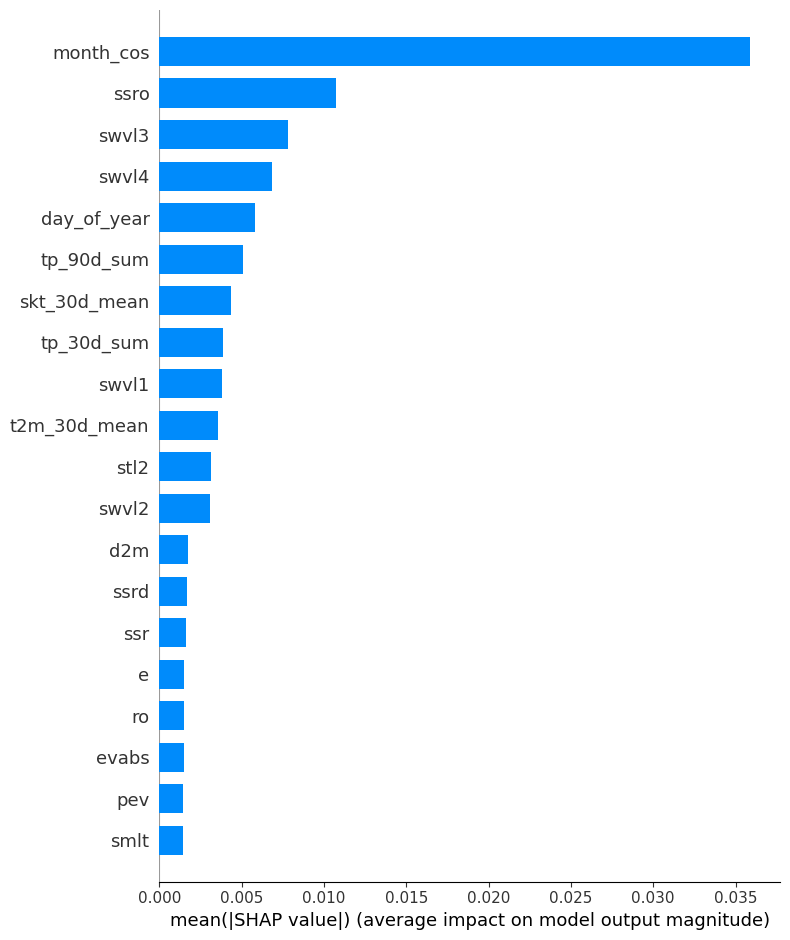

In [158]:
# Summary plot: shows mean absolute contribution of each feature
shap.summary_plot(shap_values, X_test, plot_type="bar")

C:\Users\albat\AppData\Local\Temp\ipykernel_10228\1436248343.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


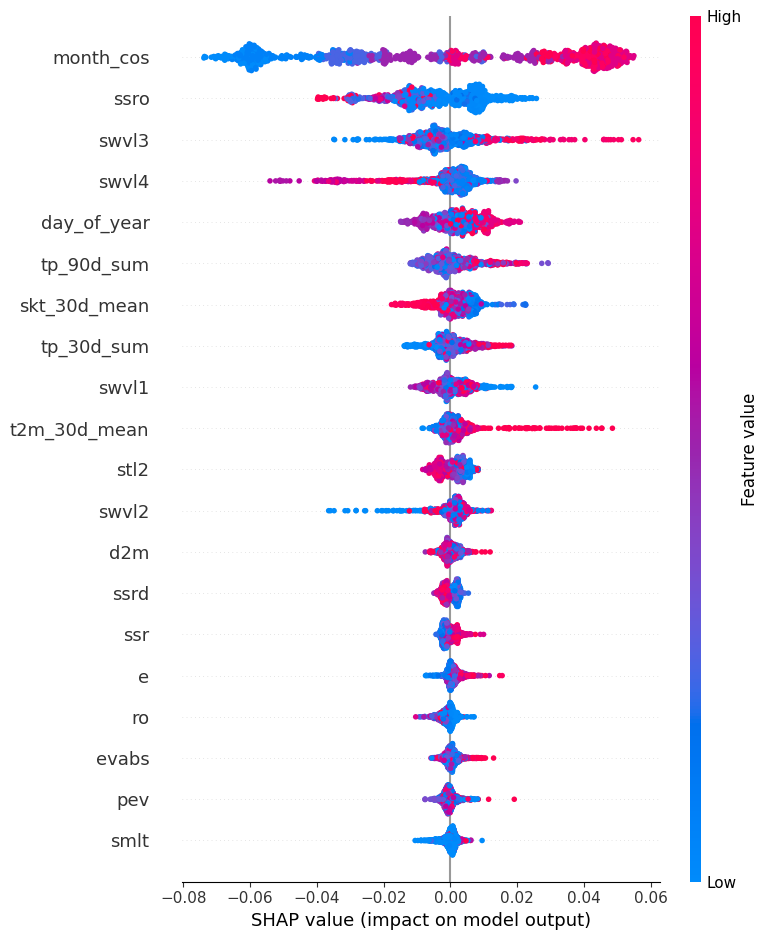

In [159]:
# Detailed dot plot: shows feature effect on each sample
shap.summary_plot(shap_values, X_test)